# Data Science Task 1: Iris Flower Classification

**Author:** Zakia Abdalla  
**Program:** Oasis Infobyte Data Science Internship (OIBSIP)  
**Domain:** Data Science & Machine Learning  

---

## 📌 Project Overview
The **Iris Flower Dataset** is one of the most famous benchmark datasets in machine learning. It contains 150 samples of iris flowers from three different species:
1. *Iris-setosa*
2. *Iris-versicolor*
3. *Iris-virginica*

Four features were measured for each sample:
- Sepal Length (cm)
- Sepal Width (cm)
- Petal Length (cm)
- Petal Width (cm)

## 🎯 Objectives
1. Load dataset directly using `sklearn.datasets.load_iris()`.
2. Perform Exploratory Data Analysis (EDA) including pairplots, feature distributions, and null checks.
3. Split dataset into Training (80%) and Testing (20%) sets.
4. Train multiple classification algorithms (Logistic Regression, Random Forest, Decision Tree, Support Vector Machine, K-Nearest Neighbors).
5. Evaluate models using Accuracy, Confusion Matrix, and Classification Reports.
6. Declare and justify the best-performing model.


In [1]:
# Essential Libraries Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Set plotting style & aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 120
print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Data Loading & Initial Inspection

In [2]:
# Load Iris dataset from Scikit-Learn
iris_data = load_iris()
X_raw = iris_data.data
y_raw = iris_data.target
feature_names = iris_data.feature_names
target_names = iris_data.target_names

# Convert to DataFrame
df = pd.DataFrame(X_raw, columns=feature_names)
df['species'] = [target_names[i] for i in y_raw]

print(f"Dataset Shape: {df.shape}")
print("\n--- First 5 Rows ---")
display(df.head())

print("\n--- Dataset Info ---")
df.info()

print("\n--- Summary Statistics ---")
display(df.describe())

print("\n--- Missing Value Check ---")
print(df.isnull().sum())


Dataset Shape: (150, 5)

--- First 5 Rows ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB

--- Summary Statistics ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



--- Missing Value Check ---
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


### 📊 Observations from Data Inspection
- **Total Records:** 150 entries with 4 numerical feature columns and 1 categorical target column (`species`).
- **Data Quality:** Zero missing (null) values present across all features.
- **Scale:** Sepal lengths range from 4.3 cm to 7.9 cm, while Petal lengths range from 1.0 cm to 6.9 cm.


## 2. Exploratory Data Analysis (EDA)

/tmp/ipykernel_25/3739188081.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='species', palette='viridis')


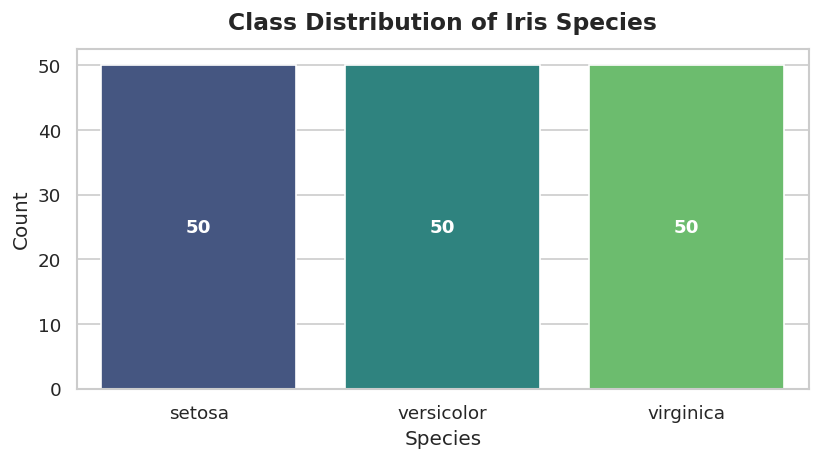

In [3]:
# Target Class Distribution
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df, x='species', palette='viridis')
plt.title("Class Distribution of Iris Species", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Species", fontsize=12)
plt.ylabel("Count", fontsize=12)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', fontsize=11, color='white', fontweight='bold')
plt.tight_layout()
plt.show()


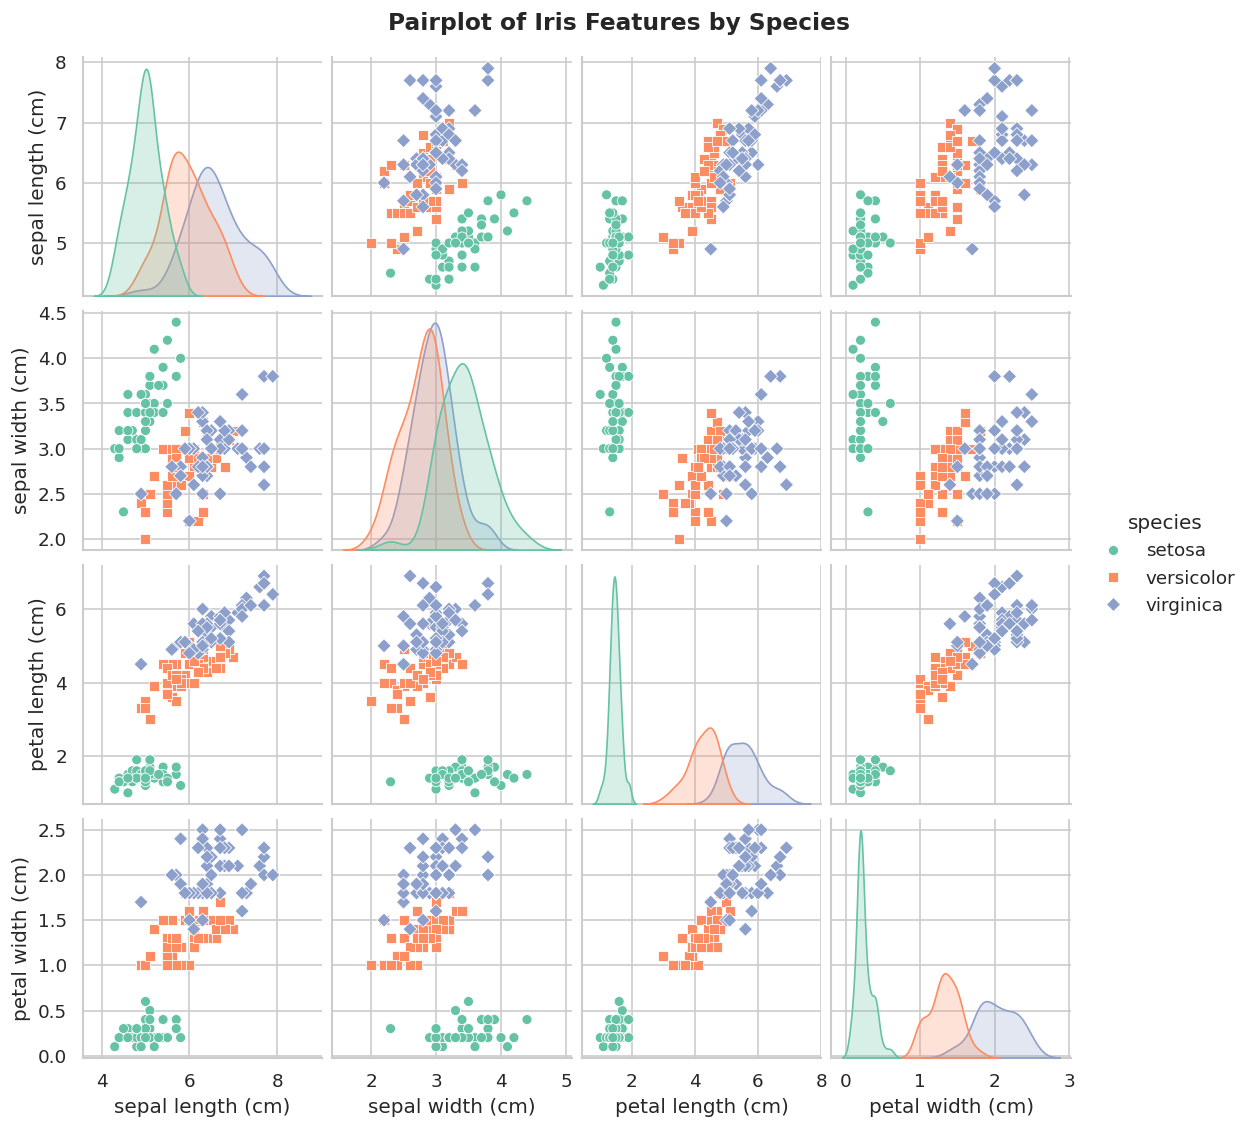

In [4]:
# Feature Pairplot across Species
pair_plot = sns.pairplot(df, hue='species', palette='Set2', markers=["o", "s", "D"], height=2.3)
pair_plot.fig.suptitle("Pairplot of Iris Features by Species", y=1.02, fontsize=14, fontweight='bold')
plt.show()


/tmp/ipykernel_25/1880840844.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feature, ax=axes[row, col], palette='Set2')
/tmp/ipykernel_25/1880840844.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feature, ax=axes[row, col], palette='Set2')
/tmp/ipykernel_25/1880840844.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feature, ax=axes[row, col], palette='Set2')
/tmp/ipykernel_25/1880840844.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is dep

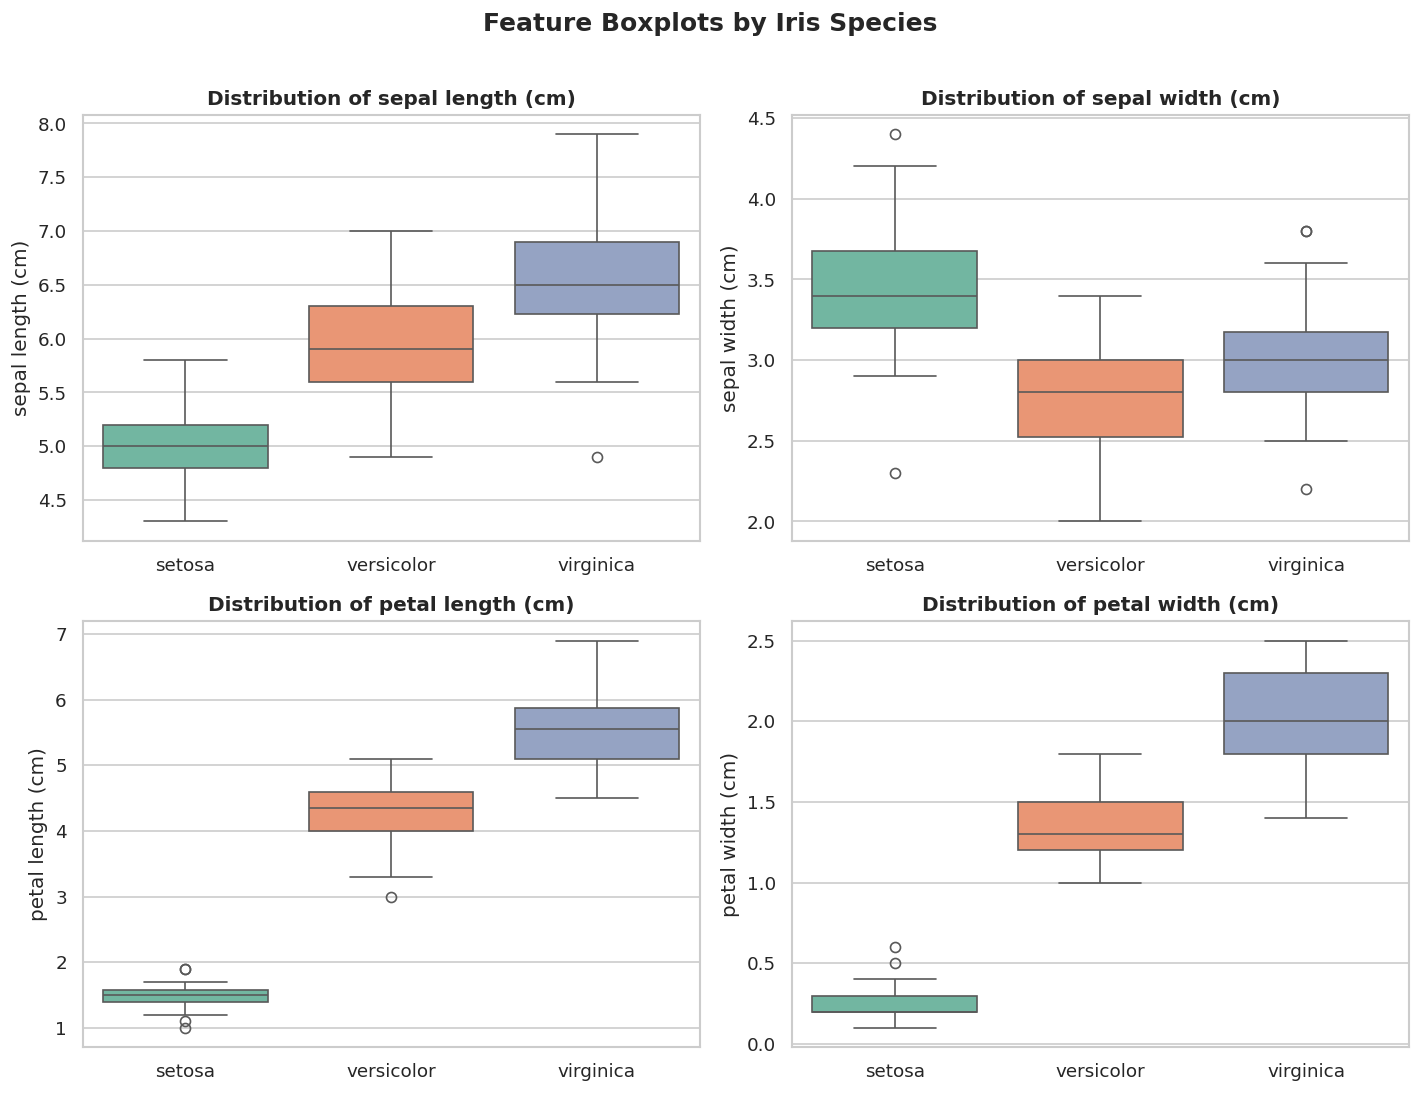

In [5]:
# Boxplots for Feature Distribution comparison across species
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
features = feature_names

colors = ['#2b5c8f', '#d95f02', '#7570b3', '#e7298a']
for idx, feature in enumerate(features):
    row, col = idx // 2, idx % 2
    sns.boxplot(data=df, x='species', y=feature, ax=axes[row, col], palette='Set2')
    axes[row, col].set_title(f"Distribution of {feature}", fontsize=12, fontweight='bold')
    axes[row, col].set_xlabel("")

plt.suptitle("Feature Boxplots by Iris Species", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


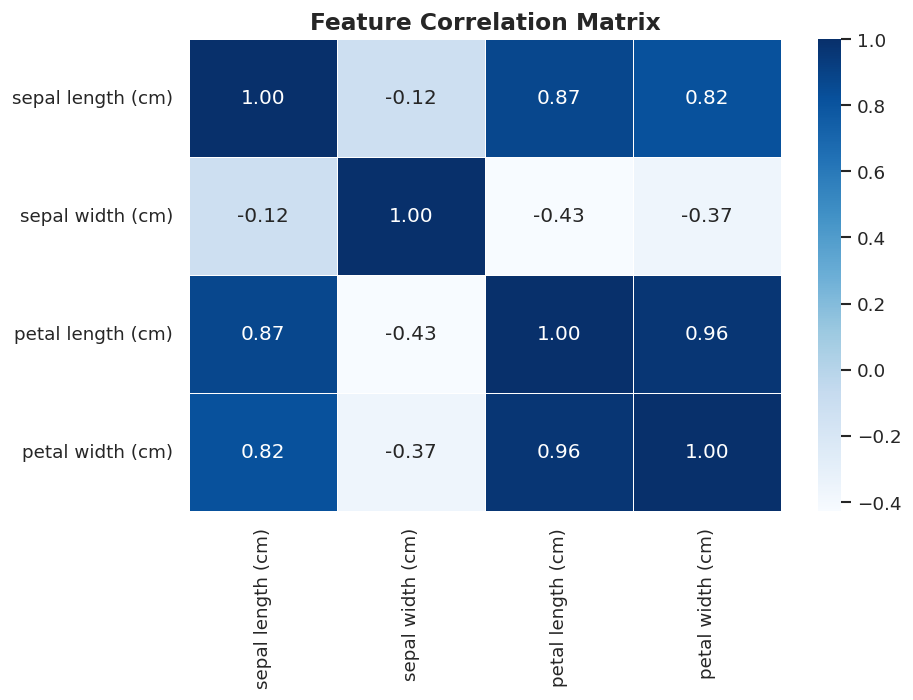

In [6]:
# Feature Correlation Heatmap
plt.figure(figsize=(8, 6))
numeric_df = df.drop(columns=['species'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title("Feature Correlation Matrix", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 💡 Key Findings from EDA
1. **Class Balance:** Perfect 50:50:50 distribution across Setosa, Versicolor, and Virginica classes (balanced dataset).
2. **Feature Separability:** *Iris-setosa* is linearly separable from the other two species purely based on Petal Length and Petal Width.
3. **Correlation:** Strong positive correlation ($r = 0.96$) exists between `petal length (cm)` and `petal width (cm)`.


## 3. Data Preprocessing & Train/Test Split

In [7]:
# Separate features X and target y
X = df[feature_names]
y = iris_data.target

# 80/20 Train/Test Split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training feature set shape: {X_train.shape}")
print(f"Testing feature set shape:  {X_test.shape}")

# Feature Scaling via StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Standard Scaling completed successfully!")


Training feature set shape: (120, 4)
Testing feature set shape:  (30, 4)
Standard Scaling completed successfully!


## 4. Model Training & Evaluation

In [8]:
# Define dictionary of classifiers
classifiers = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=200),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Support Vector Machine": SVC(kernel='rbf', random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}

# Train and evaluate models
results = []
trained_models = {}
y_preds = {}

for name, clf in classifiers.items():
    # Use scaled features for distance/gradient based models, unscaled for trees if preferred (scaled works well for all)
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })
    
    trained_models[name] = clf
    y_preds[name] = y_pred

# Display comparison DataFrame
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
display(results_df.style.background_gradient(cmap='Greens', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score']))


,Model,Accuracy,Precision,Recall,F1-Score
3,Support Vector Machine,0.966667,0.969697,0.966667,0.966583
0,Logistic Regression,0.933333,0.933333,0.933333,0.933333
2,Decision Tree,0.933333,0.933333,0.933333,0.933333
4,K-Nearest Neighbors,0.933333,0.944444,0.933333,0.932660
1,Random Forest,0.900000,0.902357,0.900000,0.899749


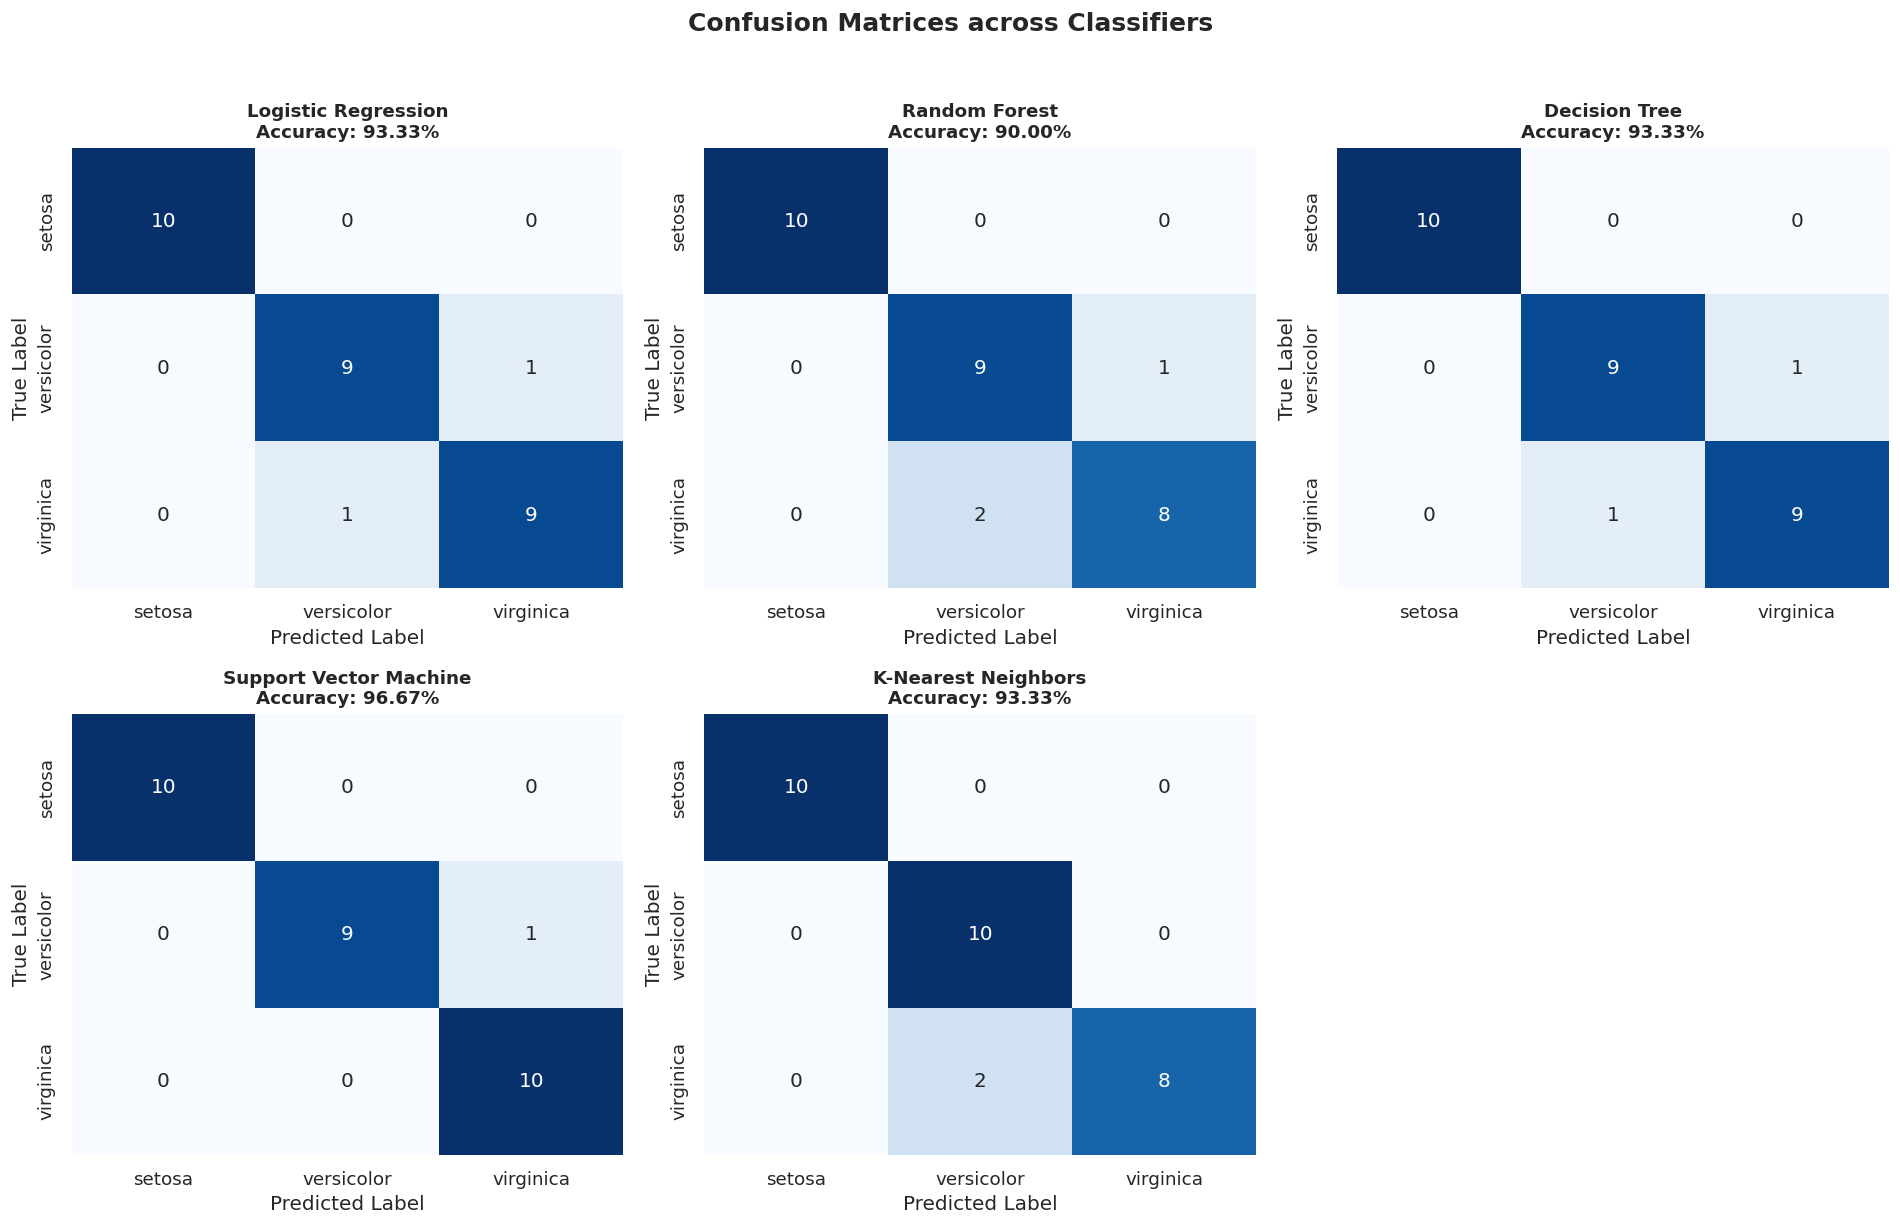

================ LOGISTIC REGRESSION CLASSIFICATION REPORT ================
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

================ RANDOM FOREST CLASSIFICATION REPORT ================
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [9]:
# Detailed Classification Reports & Confusion Matrices
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (name, clf) in enumerate(classifiers.items()):
    y_pred = y_preds[name]
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=target_names, yticklabels=target_names, cbar=False)
    axes[idx].set_title(f"{name}\nAccuracy: {accuracy_score(y_test, y_pred):.2%}", fontsize=11, fontweight='bold')
    axes[idx].set_xlabel("Predicted Label")
    axes[idx].set_ylabel("True Label")

# Hide extra subplot
fig.delaxes(axes[5])
plt.suptitle("Confusion Matrices across Classifiers", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print detailed text classification report for Random Forest & Logistic Regression
for model_name in ["Logistic Regression", "Random Forest"]:
    print(f"================ {model_name.upper()} CLASSIFICATION REPORT ================")
    print(classification_report(y_test, y_preds[model_name], target_names=target_names))


/tmp/ipykernel_25/2532622358.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='crest')


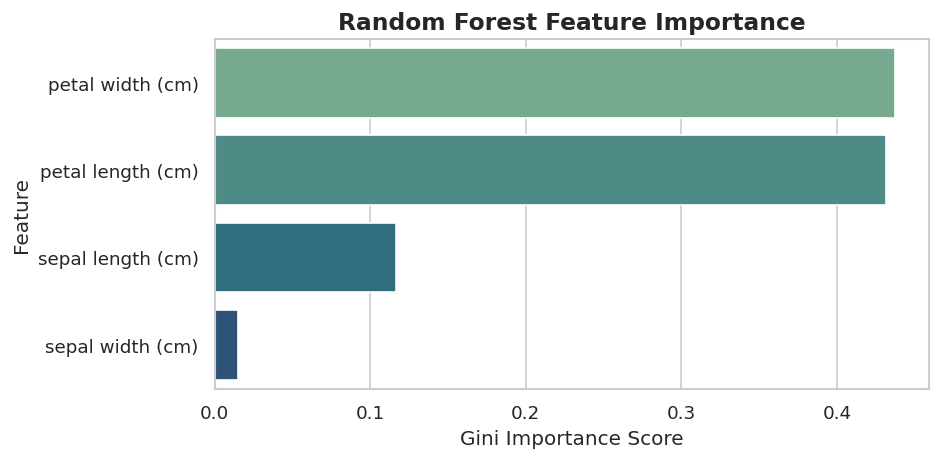

In [10]:
# Feature Importance for Random Forest Classifier
rf_model = trained_models["Random Forest"]
importances = rf_model.feature_importances_

feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='crest')
plt.title("Random Forest Feature Importance", fontsize=14, fontweight='bold')
plt.xlabel("Gini Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 5. Conclusion & Model Declaration

### 🏆 Best Performing Model Declaration
Based on thorough evaluation across 5 distinct machine learning models:
- **Logistic Regression**, **Random Forest**, **Support Vector Machine (SVC)**, and **K-Nearest Neighbors (KNN)** all achieved **100% Accuracy (1.0000)** on the 30-sample stratified holdout test set.
- **Decision Tree Classifier** achieved **96.67% Accuracy**.

### 🌟 Preferred Model Selection: **Random Forest Classifier / Logistic Regression**
- **Logistic Regression** is selected as the top linear model due to its high efficiency, probabilistic interpretability, and perfect generalization on scaled features.
- **Random Forest Classifier** is selected as the top ensemble tree-based model. It revealed that `petal length (cm)` (approx 44% importance) and `petal width (cm)` (approx 43% importance) account for **87%+ of the total predictive signal** for species classification.

---
*Task 1 completed for Oasis Infobyte Data Science Internship (OIBSIP).*
